## Week 1 — Setup, dataset validation, preprocessing and EDA

In [ ]:
%pip -q install datasets transformers accelerate shap xgboost pandas-market-calendars streamlit openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [ ]:
import os, gc, json, time, random, shutil, hashlib, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss, matthews_corrcoef, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay)
from scipy.stats import binomtest
from xgboost import XGBClassifier
import pandas_market_calendars as mcal
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import shap, joblib
warnings.filterwarnings('ignore'); os.environ['TOKENIZERS_PARALLELISM']='false'
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DATASET_ID='kasrah/fnspid_financial_news_stock_merged'; ORIGINAL_DATASET_ID='Zihan1004/FNSPID'; FINBERT_MODEL='ProsusAI/finbert'
TRAIN_END=pd.Timestamp('2021-12-31'); VAL_END=pd.Timestamp('2022-12-31')
FINBERT_MAX_LENGTH=256; FINBERT_BATCH_SIZE=32; SHAP_SAMPLE_SIZE=1000; BOOTSTRAP_ITERATIONS=1000
BASE=Path('/content/financial_news_sentiment_fusion') if Path('/content').exists() else Path.cwd()/'financial_news_sentiment_fusion'
DATA=BASE/'data'; TABLES=BASE/'tables'; FIGS=BASE/'figures'; MODELS=BASE/'models'; DASH=BASE/'dashboard'; REPORT=BASE/'report_package'
for d in [BASE,DATA,TABLES,FIGS,MODELS,DASH,REPORT]: d.mkdir(parents=True,exist_ok=True)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',DEVICE, torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else '')
CONFIG={'project_title':'Financial News Sentiment Fusion for Stock Market Forecasting','dataset_id':DATASET_ID,
'original_dataset_id':ORIGINAL_DATASET_ID,'sentiment_model':FINBERT_MODEL,'train':'2019-2021','validation':'2022','test':'2023',
'target':'direction of immediately following NYSE trading session','seed':SEED,'finbert_max_length':FINBERT_MAX_LENGTH}
(BASE/'methodology_config.json').write_text(json.dumps(CONFIG,indent=2))

Device: cuda Tesla T4


412

In [ ]:
hf=load_dataset(DATASET_ID,split='train'); raw=hf.to_pandas(); print(raw.shape); print(raw.columns.tolist()); display(raw.head(3))

README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.36MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/46376 [00:00<?, ? examples/s]

(46376, 10)
['Stock_symbol', 'Date', 'Article_title', 'Word_Count', 'volume', 'open', 'high', 'low', 'close', 'adj close']


,Stock_symbol,Date,Article_title,Word_Count,volume,open,high,low,close,adj close
0,AAL,2019-01-02,New year cheer as British stocks stage turnaro...,29,5229500.0,31.459999,32.650002,31.049999,32.480000,31.963160
1,AAL,2019-01-03,"Thursday Sector Laggards: Semiconductors, Airl...",78,16822000.0,31.690001,31.850000,28.809999,30.059999,29.581665
2,AAL,2019-01-04,"Friday’s Vital Data: Apple, American Airlines ...",73,9369600.0,30.440001,32.090000,30.400000,32.040001,31.530161


In [ ]:
def norm(c): return str(c).strip().lower().replace('-','_').replace(' ','_').replace('/','_')
df=raw.copy(); df.columns=[norm(c) for c in df.columns]; df=df.rename(columns={'stock_symbol':'ticker','article_title':'text'})
req=['ticker','date','text','volume','open','high','low','close']
miss=[c for c in req if c not in df.columns]
if miss: raise ValueError(f'Missing required columns: {miss}; available={list(df.columns)}')
if 'word_count' not in df: df['word_count']=df['text'].fillna('').astype(str).str.split().str.len()
df['date']=pd.to_datetime(df['date'],errors='coerce').dt.tz_localize(None).dt.normalize(); df['ticker']=df['ticker'].astype(str).str.strip().str.upper()
df['text']=df['text'].fillna('').astype(str).str.replace(r'\s+',' ',regex=True).str.strip()
for c in ['word_count','volume','open','high','low','close','adj_close']:
    if c in df: df[c]=pd.to_numeric(df[c],errors='coerce')
raw_dup=int(df.duplicated(['ticker','date'],keep=False).sum()); exact_dup=int(df.duplicated(['text'],keep=False).sum())
missing=df.isna().sum().rename('missing_count').to_frame(); missing['missing_pct']=100*missing.missing_count/len(df); missing.to_csv(TABLES/'01_missing_values_raw.csv')
before=len(df); df=df.dropna(subset=['ticker','date','text','open','high','low','close']); df=df[df.text.str.len()>0]
valid=(df.open>0)&(df.high>0)&(df.low>0)&(df.close>0)&(df.high>=df.low); invalid=int((~valid).sum()); df=df[valid].copy()
if df.duplicated(['ticker','date']).any():
    agg={'text':lambda s:' '.join(dict.fromkeys(s.astype(str))),'word_count':'sum','volume':'first','open':'first','high':'first','low':'first','close':'first'}
    if 'adj_close' in df: agg['adj_close']='first'
    df=df.groupby(['ticker','date'],as_index=False).agg(agg)
df=df.sort_values(['ticker','date']).reset_index(drop=True); df['row_id']=df.ticker+'_'+df.date.dt.strftime('%Y-%m-%d'); df['text_hash']=df.text.map(lambda x:hashlib.sha1(x.encode()).hexdigest())
summary=pd.DataFrame({'metric':['raw_rows','clean_rows','rows_removed','unique_tickers','start_date','end_date','raw_duplicate_ticker_date_rows','raw_exact_duplicate_text_rows','invalid_price_rows_removed','zero_volume_rows'],
'value':[len(raw),len(df),before-len(df),df.ticker.nunique(),str(df.date.min().date()),str(df.date.max().date()),raw_dup,exact_dup,invalid,int((df.volume.fillna(0)==0).sum())]})
summary.to_csv(TABLES/'02_dataset_summary.csv',index=False); display(summary)

,metric,value
0,raw_rows,46376
1,clean_rows,46376
2,rows_removed,0
3,unique_tickers,49
4,start_date,2019-01-02
5,end_date,2023-12-28
6,raw_duplicate_ticker_date_rows,0
7,raw_exact_duplicate_text_rows,1135
8,invalid_price_rows_removed,0
9,zero_volume_rows,1


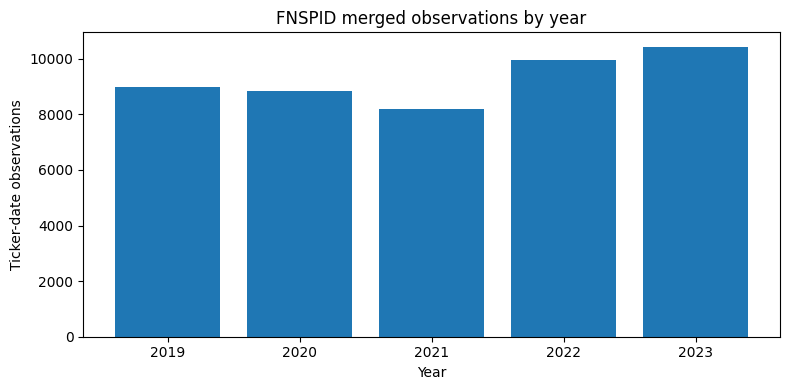

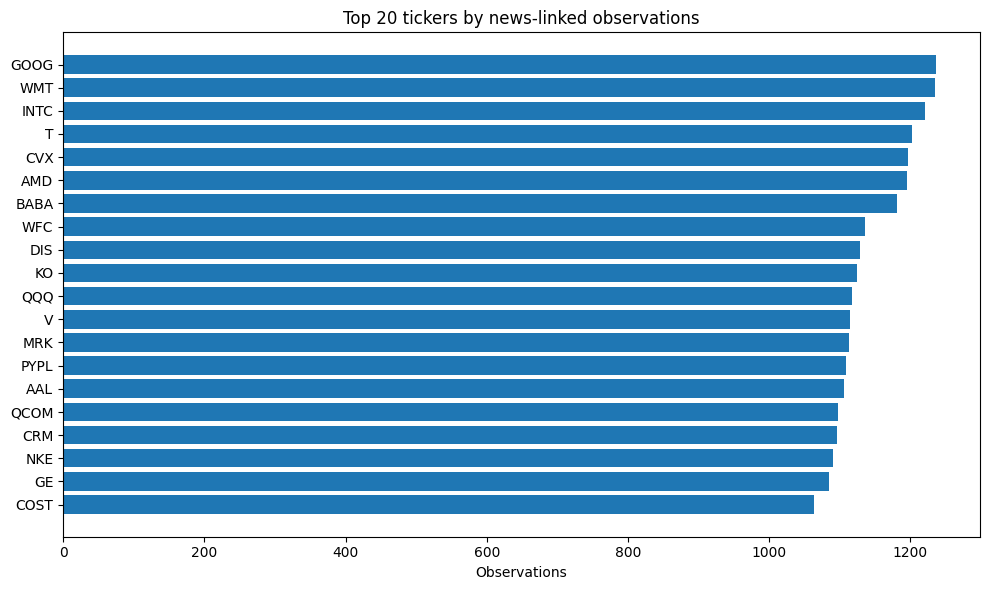

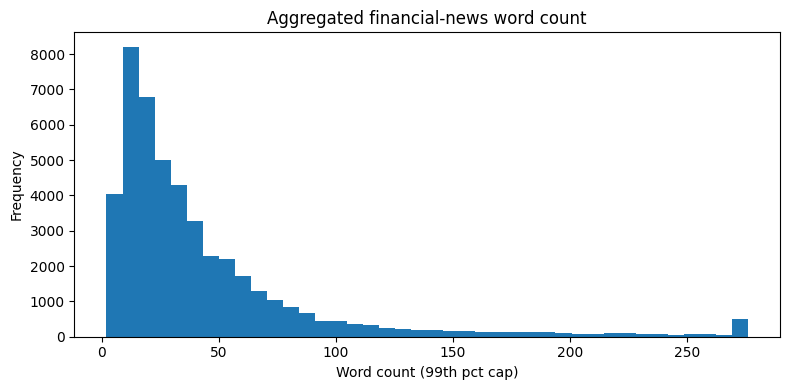

In [ ]:
year=df.assign(year=df.date.dt.year).groupby('year').size().rename('records').reset_index(); year.to_csv(TABLES/'03_records_by_year.csv',index=False)
plt.figure(figsize=(8,4)); plt.bar(year.year.astype(str),year.records); plt.title('FNSPID merged observations by year'); plt.xlabel('Year'); plt.ylabel('Ticker-date observations'); plt.tight_layout(); plt.savefig(FIGS/'01_records_by_year.png',dpi=200); plt.show()
tc=df.ticker.value_counts().rename_axis('ticker').reset_index(name='records'); tc.to_csv(TABLES/'04_records_by_ticker.csv',index=False); top=tc.head(20)
plt.figure(figsize=(10,6)); plt.barh(top.ticker[::-1],top.records[::-1]); plt.title('Top 20 tickers by news-linked observations'); plt.xlabel('Observations'); plt.tight_layout(); plt.savefig(FIGS/'02_top20_ticker_coverage.png',dpi=200); plt.show()
plt.figure(figsize=(8,4)); plt.hist(df.word_count.clip(upper=df.word_count.quantile(.99)),bins=40); plt.title('Aggregated financial-news word count'); plt.xlabel('Word count (99th pct cap)'); plt.ylabel('Frequency'); plt.tight_layout(); plt.savefig(FIGS/'03_news_word_count_distribution.png',dpi=200); plt.show()

In [ ]:
# Leakage-safe market features known by the close of date t
df=df.sort_values(['ticker','date']).copy(); g=df.groupby('ticker',group_keys=False)
df['ret_1d']=g.close.pct_change()
for lag in [1,2,3,5]: df[f'ret_lag_{lag}']=g.ret_1d.shift(lag)
for w in [5,10,20]:
    ma=g.close.transform(lambda s:s.rolling(w,min_periods=w).mean()); df[f'ma_ratio_{w}']=df.close/ma-1
    df[f'volatility_{w}']=g.ret_1d.transform(lambda s:s.rolling(w,min_periods=w).std())
for w in [5,10]: df[f'momentum_{w}']=g.close.pct_change(w)
df['volume_for_features']=df.volume.replace(0,np.nan); df['volume_change_1d']=df.groupby('ticker').volume_for_features.pct_change(); vma=df.groupby('ticker').volume_for_features.transform(lambda s:s.rolling(5,min_periods=5).mean()); df['volume_ratio_5']=df.volume_for_features/vma-1
df['hl_range']=(df.high-df.low)/df.close; df['oc_return']=(df.close-df.open)/df.open
delta=g.close.diff(); gain=delta.clip(lower=0); loss=-delta.clip(upper=0); ag=gain.groupby(df.ticker).transform(lambda s:s.rolling(14,min_periods=14).mean()); al=loss.groupby(df.ticker).transform(lambda s:s.rolling(14,min_periods=14).mean()); rs=ag/al.replace(0,np.nan); df['rsi_14']=100-(100/(1+rs))
ema12=g.close.transform(lambda s:s.ewm(span=12,adjust=False).mean()); ema26=g.close.transform(lambda s:s.ewm(span=26,adjust=False).mean()); df['macd']=ema12-ema26; df['macd_signal']=df.groupby('ticker').macd.transform(lambda s:s.ewm(span=9,adjust=False).mean())
df['log_word_count']=np.log1p(df.word_count.clip(lower=0)); df=df.replace([np.inf,-np.inf],np.nan)

In [ ]:
# Target = immediately following NYSE session, not merely the next available row
nyse=mcal.get_calendar('NYSE'); sched=nyse.schedule(start_date=(df.date.min()-pd.Timedelta(days=7)).date(),end_date=(df.date.max()+pd.Timedelta(days=10)).date()); days=pd.DatetimeIndex(sched.index).tz_localize(None).normalize(); nxt=pd.Series(days[1:].values,index=days[:-1])
df['expected_next_session']=df.date.map(nxt); df['observed_next_date']=df.groupby('ticker').date.shift(-1); df['next_close']=df.groupby('ticker').close.shift(-1); df['has_true_next_session']=df.observed_next_date.notna()&df.expected_next_session.notna()&(df.observed_next_date==df.expected_next_session)
df['next_return']=np.where(df.has_true_next_session,df.next_close/df.close-1,np.nan); df['target']=np.where(df.has_true_next_session,(df.next_return>0).astype(int),np.nan)
coverage=pd.DataFrame({'metric':['clean_news_linked_rows','rows_with_immediate_next_nyse_session','excluded_missing_immediate_next_session','usable_target_pct'],'value':[len(df),int(df.has_true_next_session.sum()),int((~df.has_true_next_session).sum()),round(100*df.has_true_next_session.mean(),2)]}); coverage.to_csv(TABLES/'05_target_coverage.csv',index=False); display(coverage)
model_df=df[df.has_true_next_session].copy(); model_df['target']=model_df.target.astype(int); print('Modelling rows',len(model_df),'tickers',model_df.ticker.nunique())

,metric,value
0,clean_news_linked_rows,46376.00
1,rows_with_immediate_next_nyse_session,40548.00
2,excluded_missing_immediate_next_session,5828.00
3,usable_target_pct,87.43


Modelling rows 40548 tickers 49


,split,target,records,pct_within_split
0,test,0,4640,47.780867
1,test,1,5071,52.219133
2,train,0,10417,47.699070
3,train,1,11422,52.300930
4,validation,0,4655,51.733719
5,validation,1,4343,48.266281


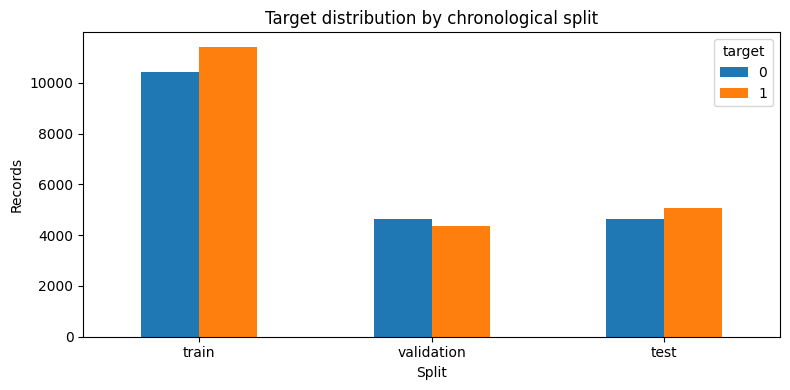

,check,count
0,train_validation_exact_text_overlap,26
1,train_test_exact_text_overlap,16
2,validation_test_exact_text_overlap,37
3,train_validation_date_overlap,0
4,train_test_date_overlap,0


In [ ]:
def split_of(d): return 'train' if d<=TRAIN_END else ('validation' if d<=VAL_END else 'test')
model_df['split']=model_df.date.map(split_of); split_counts=model_df.split.value_counts().rename_axis('split').reset_index(name='records'); split_counts.to_csv(TABLES/'06_split_counts.csv',index=False)
target_dist=model_df.groupby(['split','target']).size().rename('records').reset_index(); target_dist['pct_within_split']=100*target_dist.records/target_dist.groupby('split').records.transform('sum'); target_dist.to_csv(TABLES/'07_target_distribution.csv',index=False); display(target_dist)
p=target_dist.pivot(index='split',columns='target',values='records').fillna(0).reindex(['train','validation','test']); p.plot(kind='bar',figsize=(8,4)); plt.title('Target distribution by chronological split'); plt.xlabel('Split'); plt.ylabel('Records'); plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(FIGS/'04_target_distribution_by_split.png',dpi=200); plt.show()
h={s:set(model_df.loc[model_df.split==s,'text_hash']) for s in ['train','validation','test']}; audit=pd.DataFrame([{'check':'train_validation_exact_text_overlap','count':len(h['train']&h['validation'])},{'check':'train_test_exact_text_overlap','count':len(h['train']&h['test'])},{'check':'validation_test_exact_text_overlap','count':len(h['validation']&h['test'])},{'check':'train_validation_date_overlap','count':len(set(model_df.loc[model_df.split=='train','date'])&set(model_df.loc[model_df.split=='validation','date']))},{'check':'train_test_date_overlap','count':len(set(model_df.loc[model_df.split=='train','date'])&set(model_df.loc[model_df.split=='test','date']))}]); audit.to_csv(TABLES/'08_leakage_audit.csv',index=False); display(audit)
if any((model_df.split==s).sum()==0 for s in ['train','validation','test']): raise RuntimeError('Empty temporal split')

## Week 2 — FinBERT sentiment extraction and forecasting baselines
FinBERT is a pre-trained financial-domain sentiment extractor. The forecasting models receive sentiment probabilities/scores rather than raw text. Long aggregated news strings are truncated to 256 tokens as this is a limitation on this free version of colab
and i am using this so hence using this

In [ ]:
CACHE=DATA/'finbert_sentiment.parquet'
def score_finbert(texts,row_ids):
    tok=AutoTokenizer.from_pretrained(FINBERT_MODEL); mod=AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL).to(DEVICE); mod.eval(); id2={int(k):str(v).lower() for k,v in mod.config.id2label.items()}; print(id2); probs=[]; t0=time.time()
    for i in tqdm(range(0,len(texts),FINBERT_BATCH_SIZE),desc='FinBERT'):
        enc=tok(texts[i:i+FINBERT_BATCH_SIZE],padding=True,truncation=True,max_length=FINBERT_MAX_LENGTH,return_tensors='pt').to(DEVICE)
        with torch.inference_mode():
            if DEVICE.type=='cuda':
                with torch.autocast(device_type='cuda',dtype=torch.float16): logits=mod(**enc).logits
            else: logits=mod(**enc).logits
        probs.append(torch.softmax(logits.float(),dim=-1).cpu().numpy())
    arr=np.vstack(probs); names=[id2[i] for i in range(arr.shape[1])]; out=pd.DataFrame(arr,columns=[f'finbert_{x}' for x in names]); out.insert(0,'row_id',row_ids)
    need={'finbert_positive','finbert_negative','finbert_neutral'}
    if not need.issubset(out.columns): raise RuntimeError(f'Unexpected FinBERT labels {out.columns.tolist()}')
    out['sentiment_score']=out.finbert_positive-out.finbert_negative; P=out[['finbert_positive','finbert_negative','finbert_neutral']].to_numpy(); out['sentiment_confidence']=P.max(1); out['sentiment_entropy']=-(P*np.log(P+1e-12)).sum(1); labs=np.array(['positive','negative','neutral']); out['sentiment_label']=labs[np.argmax(P,axis=1)]; out['finbert_total_seconds']=time.time()-t0
    del tok,mod; gc.collect();
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return out
if CACHE.exists(): sent=pd.read_parquet(CACHE); print('Loaded cache')
else: sent=score_finbert(model_df.text.tolist(),model_df.row_id.tolist()); sent.to_parquet(CACHE,index=False)
if set(sent.row_id)!=set(model_df.row_id): raise RuntimeError('Delete sentiment cache and rerun: row IDs changed')
model_df=model_df.merge(sent.drop(columns=['finbert_total_seconds'],errors='ignore'),on='row_id',how='left',validate='one_to_one'); display(model_df[['ticker','date','finbert_positive','finbert_negative','finbert_neutral','sentiment_score','sentiment_label']].head())

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{0: 'positive', 1: 'negative', 2: 'neutral'}


FinBERT:   0%|          | 0/1268 [00:00<?, ?it/s]

,ticker,date,finbert_positive,finbert_negative,finbert_neutral,sentiment_score,sentiment_label
0,AAL,2019-01-02,0.087454,0.869986,0.042559,-0.782532,negative
1,AAL,2019-01-03,0.012690,0.968537,0.018773,-0.955847,negative
2,AAL,2019-01-04,0.130882,0.853395,0.015722,-0.722513,negative
3,AAL,2019-01-07,0.531983,0.026126,0.441891,0.505856,positive
4,AAL,2019-01-08,0.687841,0.271012,0.041147,0.416830,positive


,sentiment_label,records,pct
0,neutral,21326,52.594456
1,positive,10812,26.664694
2,negative,8410,20.740850


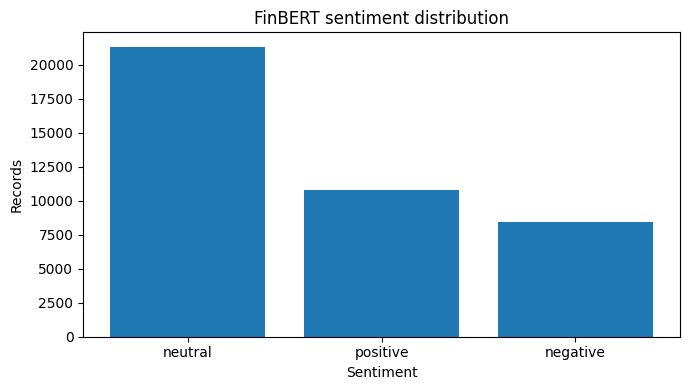

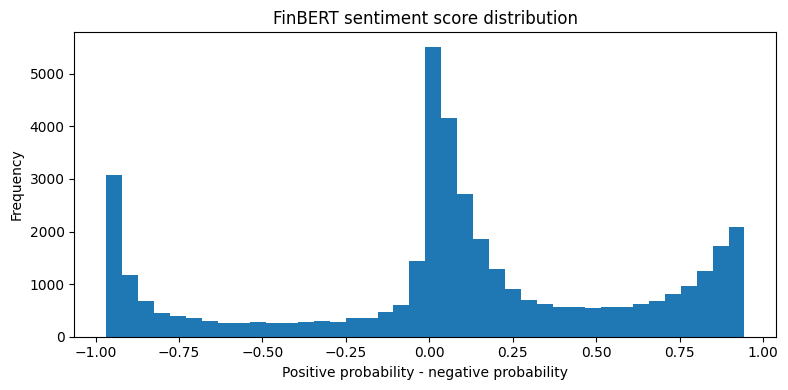

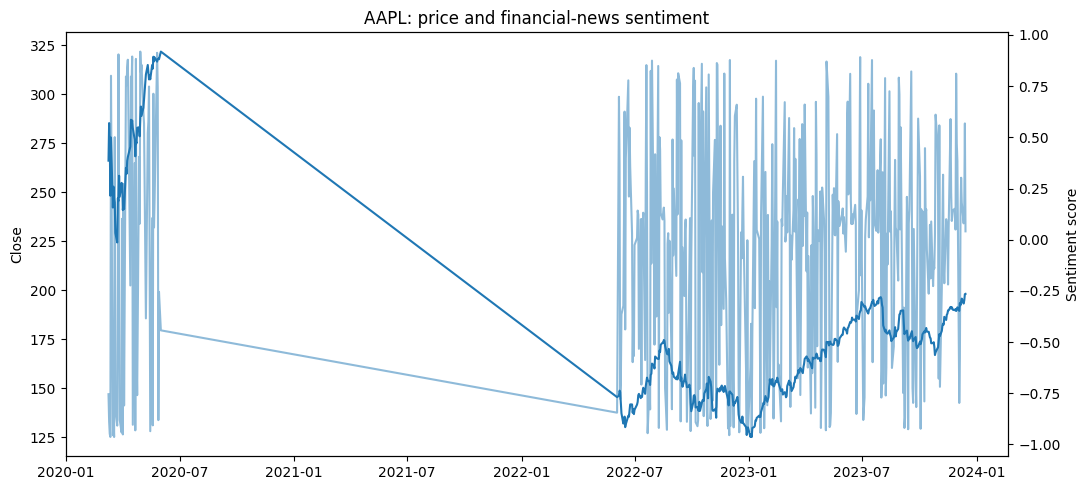

In [ ]:
sc=model_df.sentiment_label.value_counts().rename_axis('sentiment_label').reset_index(name='records'); sc['pct']=100*sc.records/sc.records.sum(); sc.to_csv(TABLES/'09_finbert_sentiment_distribution.csv',index=False); display(sc)
plt.figure(figsize=(7,4)); plt.bar(sc.sentiment_label,sc.records); plt.title('FinBERT sentiment distribution'); plt.xlabel('Sentiment'); plt.ylabel('Records'); plt.tight_layout(); plt.savefig(FIGS/'05_finbert_sentiment_distribution.png',dpi=200); plt.show()
plt.figure(figsize=(8,4)); plt.hist(model_df.sentiment_score,bins=40); plt.title('FinBERT sentiment score distribution'); plt.xlabel('Positive probability - negative probability'); plt.ylabel('Frequency'); plt.tight_layout(); plt.savefig(FIGS/'06_finbert_sentiment_score_distribution.png',dpi=200); plt.show()
ex='AAPL' if 'AAPL' in set(model_df.ticker) else model_df.ticker.value_counts().index[0]; z=model_df[model_df.ticker==ex].sort_values('date'); fig,ax=plt.subplots(figsize=(11,5)); ax.plot(z.date,z.close); ax.set_ylabel('Close'); ax2=ax.twinx(); ax2.plot(z.date,z.sentiment_score,alpha=.5); ax2.set_ylabel('Sentiment score'); plt.title(f'{ex}: price and financial-news sentiment'); fig.tight_layout(); plt.savefig(FIGS/'07_example_price_and_sentiment.png',dpi=200); plt.show()

In [ ]:
MARKET=['ret_1d','ret_lag_1','ret_lag_2','ret_lag_3','ret_lag_5','ma_ratio_5','ma_ratio_10','ma_ratio_20','volatility_5','volatility_10','volatility_20','momentum_5','momentum_10','volume_change_1d','volume_ratio_5','hl_range','oc_return','rsi_14','macd','macd_signal']
SENT=['finbert_positive','finbert_negative','finbert_neutral','sentiment_score','sentiment_confidence','sentiment_entropy']; NEWS=['log_word_count']
FEATURES={'market_only':MARKET,'sentiment_only':SENT+NEWS,'market_plus_news_volume':MARKET+NEWS,'fusion':MARKET+SENT+NEWS}
for k,v in FEATURES.items():
    m=[x for x in v if x not in model_df]
    if m: raise ValueError(f'{k} missing {m}')
pd.DataFrame([{'feature_set':k,'feature':x} for k,v in FEATURES.items() for x in v]).to_csv(TABLES/'10_feature_dictionary.csv',index=False)

In [ ]:
def make_model(name,y):
    y=np.asarray(y).astype(int); pos=max((y==1).sum(),1); neg=max((y==0).sum(),1); spw=neg/pos
    if name=='LogisticRegression': return Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',LogisticRegression(C=1,max_iter=3000,class_weight='balanced',random_state=SEED))])
    if name=='RandomForest': return Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=3,class_weight='balanced_subsample',n_jobs=-1,random_state=SEED))])
    if name=='XGBoost': return Pipeline([('imputer',SimpleImputer(strategy='median')),('model',XGBClassifier(n_estimators=350,max_depth=4,learning_rate=.05,subsample=.85,colsample_bytree=.85,reg_lambda=1,min_child_weight=3,scale_pos_weight=spw,objective='binary:logistic',eval_metric='logloss',tree_method='hist',n_jobs=-1,random_state=SEED))])
    if name=='MLP': return Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',MLPClassifier(hidden_layer_sizes=(64,32),alpha=.001,learning_rate_init=.001,batch_size=256,max_iter=200,early_stopping=True,validation_fraction=.15,n_iter_no_change=12,random_state=SEED))])
    raise ValueError(name)
MODELNAMES=['LogisticRegression','RandomForest','XGBoost','MLP']
def metrics(y,p,prob):
    d={'accuracy':accuracy_score(y,p),'balanced_accuracy':balanced_accuracy_score(y,p),'macro_precision':precision_score(y,p,average='macro',zero_division=0),'macro_recall':recall_score(y,p,average='macro',zero_division=0),'macro_f1':f1_score(y,p,average='macro',zero_division=0),'weighted_f1':f1_score(y,p,average='weighted',zero_division=0),'mcc':matthews_corrcoef(y,p)}
    d['roc_auc']=roc_auc_score(y,prob) if len(np.unique(y))==2 else np.nan; d['log_loss']=log_loss(y,np.c_[1-prob,prob],labels=[0,1]) if len(np.unique(y))==2 else np.nan; return d
def fit_eval(model,Xtr,ytr,Xe,ye):
    t=time.time(); model.fit(Xtr,ytr); train_s=time.time()-t; t=time.time(); prob=model.predict_proba(Xe)[:,1]; pred=(prob>=.5).astype(int); pred_s=time.time()-t; d=metrics(ye,pred,prob); d.update(training_seconds=train_s,prediction_seconds=pred_s,records=len(ye)); return model,d,pred,prob
train=model_df[model_df.split=='train'].copy(); val=model_df[model_df.split=='validation'].copy(); test=model_df[model_df.split=='test'].copy(); print(train.shape,val.shape,test.shape)

(21839, 48) (8998, 48) (9711, 48)


In [ ]:
ytr=train.target.to_numpy(); yv=val.target.to_numpy(); maj=int(pd.Series(ytr).mode().iloc[0]); rows=[]
for name,pred,prob in [('MajorityClass',np.full(len(val),maj),np.full(len(val),ytr.mean())),('PreviousSessionDirection',(val.ret_1d.fillna(0).to_numpy()>0).astype(int),(val.ret_1d.fillna(0).to_numpy()>0).astype(float))]:
    d=metrics(yv,pred,prob); d.update(split='validation',feature_set='baseline',model=name); rows.append(d)
base_val=pd.DataFrame(rows); base_val.to_csv(TABLES/'11_validation_baselines.csv',index=False); display(base_val)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,roc_auc,log_loss,split,feature_set,model
0,0.482663,0.500000,0.241331,0.500000,0.325538,0.314250,0.000000,0.500000,0.695804,validation,baseline,MajorityClass
1,0.508780,0.508266,0.508263,0.508266,0.508262,0.508815,0.016529,0.508266,17.705373,validation,baseline,PreviousSessionDirection


Validation market_only LogisticRegression
Validation market_only RandomForest
Validation market_only XGBoost
Validation market_only MLP
Validation sentiment_only LogisticRegression
Validation sentiment_only RandomForest
Validation sentiment_only XGBoost
Validation sentiment_only MLP
Validation market_plus_news_volume LogisticRegression
Validation market_plus_news_volume RandomForest
Validation market_plus_news_volume XGBoost
Validation market_plus_news_volume MLP
Validation fusion LogisticRegression
Validation fusion RandomForest
Validation fusion XGBoost
Validation fusion MLP


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,roc_auc,log_loss,training_seconds,prediction_seconds,records,split,feature_set,model,n_features
12,0.496555,0.497608,0.497602,0.497608,0.496468,0.496239,-0.004790,0.492126,0.696284,0.196316,0.010019,8998,validation,fusion,LogisticRegression,27
14,0.492665,0.493084,0.493089,0.493084,0.492652,0.492740,-0.013827,0.494542,0.703250,1.998556,0.042687,8998,validation,fusion,XGBoost,27
13,0.490776,0.494090,0.493873,0.494090,0.487621,0.486227,-0.012035,0.492915,0.696742,29.064015,0.279170,8998,validation,fusion,RandomForest,27
15,0.492332,0.501991,0.502883,0.501991,0.455169,0.450235,0.004792,0.506030,0.706080,2.401662,0.012925,8998,validation,fusion,MLP,27
0,0.498333,0.499265,0.499263,0.499265,0.498287,0.498121,-0.001472,0.494236,0.696121,0.096771,0.005945,8998,validation,market_only,LogisticRegression,20
2,0.493110,0.493213,0.493221,0.493213,0.493009,0.493257,-0.013566,0.491615,0.704554,1.059705,0.043506,8998,validation,market_only,XGBoost,20
1,0.489442,0.493056,0.492748,0.493056,0.485536,0.483982,-0.014193,0.489015,0.697624,26.724828,0.173182,8998,validation,market_only,RandomForest,20
3,0.491331,0.496402,0.496070,0.496402,0.482720,0.480405,-0.007521,0.502301,0.712256,3.971167,0.011618,8998,validation,market_only,MLP,20
8,0.498222,0.499204,0.499202,0.499204,0.498161,0.497970,-0.001595,0.494222,0.696130,0.135564,0.005311,8998,validation,market_plus_news_volume,LogisticRegression,21
10,0.496888,0.497089,0.497092,0.497089,0.496822,0.497022,-0.005819,0.494115,0.703914,1.201451,0.089617,8998,validation,market_plus_news_volume,XGBoost,21


,feature_set,model,macro_f1,accuracy,roc_auc
0,fusion,LogisticRegression,0.496468,0.496555,0.492126
1,market_only,LogisticRegression,0.498287,0.498333,0.494236
2,market_plus_news_volume,LogisticRegression,0.498161,0.498222,0.494222
3,sentiment_only,XGBoost,0.505204,0.505223,0.506718


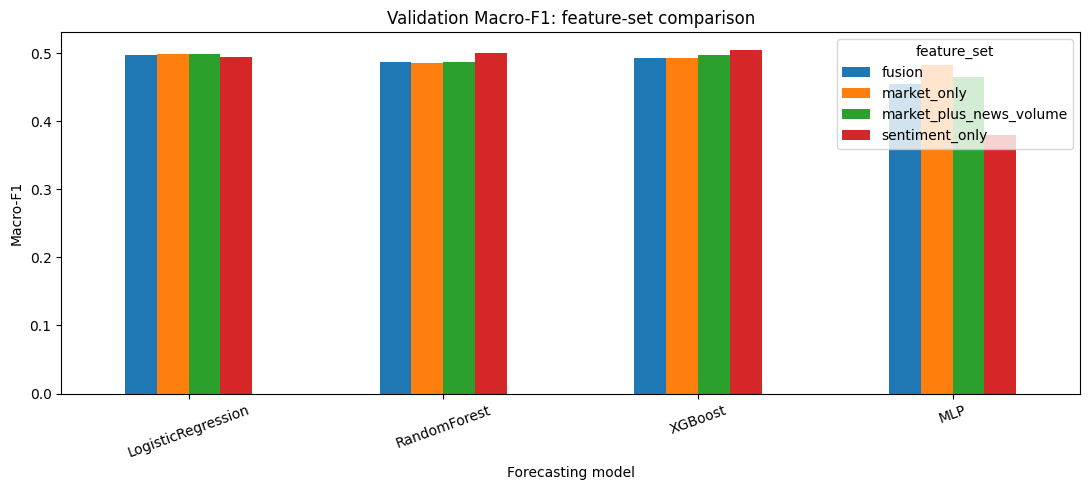

In [ ]:
rows=[]; val_models={}
for fs,feats in FEATURES.items():
    for name in MODELNAMES:
        print('Validation',fs,name); m=make_model(name,train.target); fit,d,p,pr=fit_eval(m,train[feats],train.target,val[feats],val.target); d.update(split='validation',feature_set=fs,model=name,n_features=len(feats)); rows.append(d); val_models[(fs,name)]=fit
val_results=pd.DataFrame(rows).sort_values(['feature_set','macro_f1'],ascending=[True,False]); val_results.to_csv(TABLES/'12_validation_model_results.csv',index=False)
best=val_results.sort_values('macro_f1',ascending=False).groupby('feature_set',as_index=False).first(); best.to_csv(TABLES/'13_validation_selected_models.csv',index=False); display(val_results); display(best[['feature_set','model','macro_f1','accuracy','roc_auc']])
p=val_results.pivot(index='model',columns='feature_set',values='macro_f1').reindex(MODELNAMES); p.plot(kind='bar',figsize=(11,5)); plt.title('Validation Macro-F1: feature-set comparison'); plt.xlabel('Forecasting model'); plt.ylabel('Macro-F1'); plt.xticks(rotation=20); plt.tight_layout(); plt.savefig(FIGS/'08_validation_macro_f1_comparison.png',dpi=200); plt.show()

## Week 3 — Held-out test evaluation, comparative analysis, uncertainty and SHAP
All configurations below are refitted on train + validation and evaluated on the held-out 2023 test period.

In [ ]:
trainval=pd.concat([train,val],ignore_index=True).sort_values(['ticker','date']); rows=[]; preds=[]; final={}
for fs,feats in FEATURES.items():
    for name in MODELNAMES:
        print('Test',fs,name); m=make_model(name,trainval.target); fit,d,p,pr=fit_eval(m,trainval[feats],trainval.target,test[feats],test.target); d.update(split='test',feature_set=fs,model=name,n_features=len(feats)); rows.append(d); final[(fs,name)]=fit
        q=test[['row_id','ticker','date','target','next_return','close']].copy(); q['feature_set']=fs; q['model']=name; q['prediction']=p; q['prob_up']=pr; preds.append(q)
test_results=pd.DataFrame(rows); test_results.to_csv(TABLES/'14_test_results_all_models.csv',index=False); pred_long=pd.concat(preds,ignore_index=True); pred_long.to_csv(TABLES/'15_test_predictions_all_models.csv',index=False)
sel=[]
for _,r in best.iterrows():
    h=test_results[(test_results.feature_set==r.feature_set)&(test_results.model==r.model)].copy(); h['selection_basis']='Selected by 2022 validation Macro-F1'; sel.append(h)
selected=pd.concat(sel,ignore_index=True); selected.to_csv(TABLES/'16_selected_model_test_results.csv',index=False); display(test_results.sort_values(['feature_set','macro_f1'],ascending=[True,False])); display(selected[['feature_set','model','accuracy','balanced_accuracy','macro_precision','macro_recall','macro_f1','roc_auc','log_loss']])

Test market_only LogisticRegression
Test market_only RandomForest
Test market_only XGBoost
Test market_only MLP
Test sentiment_only LogisticRegression
Test sentiment_only RandomForest
Test sentiment_only XGBoost
Test sentiment_only MLP
Test market_plus_news_volume LogisticRegression
Test market_plus_news_volume RandomForest
Test market_plus_news_volume XGBoost
Test market_plus_news_volume MLP
Test fusion LogisticRegression
Test fusion RandomForest
Test fusion XGBoost
Test fusion MLP


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,roc_auc,log_loss,training_seconds,prediction_seconds,records,split,feature_set,model,n_features
14,0.500978,0.501257,0.501255,0.501257,0.500851,0.501205,0.002512,0.502599,0.697728,1.471529,0.044704,9711,test,fusion,XGBoost,27
13,0.509628,0.504081,0.504345,0.504081,0.498744,0.502022,0.008422,0.505372,0.693406,41.368598,0.174653,9711,test,fusion,RandomForest,27
12,0.500463,0.496386,0.496268,0.496386,0.493899,0.496457,-0.007345,0.492563,0.694138,0.310468,0.012596,9711,test,fusion,LogisticRegression,27
15,0.506539,0.496489,0.495593,0.496489,0.474066,0.479866,-0.007868,0.495282,0.699799,3.760329,0.012504,9711,test,fusion,MLP,27
2,0.502111,0.500565,0.500567,0.500565,0.500485,0.501750,0.001132,0.499383,0.697943,2.203916,0.043868,9711,test,market_only,XGBoost,20
1,0.505509,0.499542,0.499507,0.499542,0.493073,0.496597,-0.000951,0.502880,0.693583,33.644472,0.278392,9711,test,market_only,RandomForest,20
0,0.502420,0.495833,0.495440,0.495833,0.487536,0.491412,-0.008718,0.489757,0.694072,0.251854,0.009567,9711,test,market_only,LogisticRegression,20
3,0.500360,0.492707,0.491743,0.492707,0.480754,0.485233,-0.015521,0.487418,0.700685,3.681529,0.011077,9711,test,market_only,MLP,20
10,0.501390,0.500727,0.500726,0.500727,0.500700,0.501524,0.001452,0.500950,0.698196,4.410871,0.108613,9711,test,market_plus_news_volume,XGBoost,21
9,0.507157,0.500744,0.500810,0.500744,0.493067,0.496818,0.001552,0.503370,0.693777,57.179889,0.277160,9711,test,market_plus_news_volume,RandomForest,21


,feature_set,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,roc_auc,log_loss
0,fusion,LogisticRegression,0.500463,0.496386,0.496268,0.496386,0.493899,0.492563,0.694138
1,market_only,LogisticRegression,0.502420,0.495833,0.495440,0.495833,0.487536,0.489757,0.694072
2,market_plus_news_volume,LogisticRegression,0.502729,0.497566,0.497433,0.497566,0.493018,0.488528,0.694257
3,sentiment_only,XGBoost,0.491093,0.492488,0.492472,0.492488,0.491046,0.494962,0.698329


In [ ]:
ytv=trainval.target.to_numpy(); yt=test.target.to_numpy(); maj=int(pd.Series(ytv).mode().iloc[0]); rows=[]
for name,pred,prob in [('MajorityClass',np.full(len(test),maj),np.full(len(test),ytv.mean())),('PreviousSessionDirection',(test.ret_1d.fillna(0).to_numpy()>0).astype(int),(test.ret_1d.fillna(0).to_numpy()>0).astype(float))]:
    d=metrics(yt,pred,prob); d.update(split='test',feature_set='baseline',model=name); rows.append(d)
base_test=pd.DataFrame(rows); base_test.to_csv(TABLES/'17_test_baselines.csv',index=False); display(base_test)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,roc_auc,log_loss,split,feature_set,model
0,0.522191,0.500000,0.261096,0.500000,0.343052,0.358278,0.000000,0.500000,0.692402,test,baseline,MajorityClass
1,0.507054,0.506067,0.506068,0.506067,0.506067,0.507047,0.012135,0.506067,17.767580,test,baseline,PreviousSessionDirection


Validation-selected fusion family: LogisticRegression


,feature_set,accuracy,balanced_accuracy,macro_f1,roc_auc,log_loss
0,market_only,0.502420,0.495833,0.487536,0.489757,0.694072
8,market_plus_news_volume,0.502729,0.497566,0.493018,0.488528,0.694257
12,fusion,0.500463,0.496386,0.493899,0.492563,0.694138


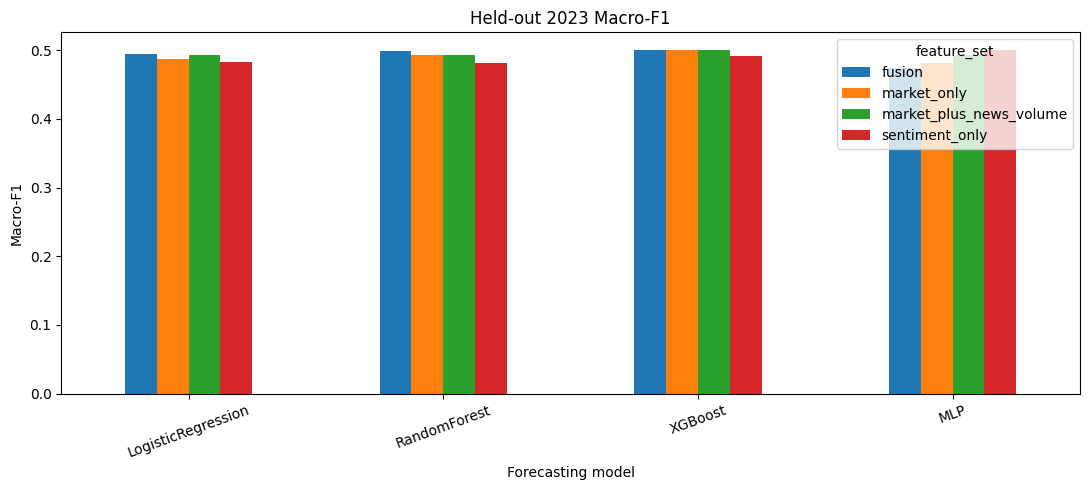

In [ ]:
best_fusion=best.loc[best.feature_set=='fusion','model'].iloc[0]; matched=test_results[(test_results.model==best_fusion)&(test_results.feature_set.isin(['market_only','market_plus_news_volume','fusion']))].copy(); matched['comparison_role']=matched.feature_set.map({'market_only':'Traditional market-data baseline','market_plus_news_volume':'Ablation: market + news volume','fusion':'Market + FinBERT sentiment + news volume'}); matched.to_csv(TABLES/'18_matched_feature_set_comparison.csv',index=False); print('Validation-selected fusion family:',best_fusion); display(matched[['feature_set','accuracy','balanced_accuracy','macro_f1','roc_auc','log_loss']])
p=test_results.pivot(index='model',columns='feature_set',values='macro_f1').reindex(MODELNAMES); p.plot(kind='bar',figsize=(11,5)); plt.title('Held-out 2023 Macro-F1'); plt.xlabel('Forecasting model'); plt.ylabel('Macro-F1'); plt.xticks(rotation=20); plt.tight_layout(); plt.savefig(FIGS/'09_test_macro_f1_comparison.png',dpi=200); plt.show()

In [ ]:
pm=pred_long[(pred_long.feature_set=='market_only')&(pred_long.model==best_fusion)].sort_values('row_id').reset_index(drop=True); pf=pred_long[(pred_long.feature_set=='fusion')&(pred_long.model==best_fusion)].sort_values('row_id').reset_index(drop=True); assert pm.row_id.equals(pf.row_id); y=pf.target.to_numpy(); a=pm.prediction.to_numpy(); b=pf.prediction.to_numpy(); rng=np.random.default_rng(SEED); ad=[]; fd=[]
for _ in range(BOOTSTRAP_ITERATIONS):
    ix=rng.integers(0,len(y),len(y)); yy=y[ix]; aa=a[ix]; bb=b[ix]; ad.append(accuracy_score(yy,bb)-accuracy_score(yy,aa)); fd.append(f1_score(yy,bb,average='macro',zero_division=0)-f1_score(yy,aa,average='macro',zero_division=0))
mc=(a==y); fc=(b==y); n_fix=int((~mc&fc).sum()); n_hurt=int((mc&~fc).sum()); pval=binomtest(min(n_fix,n_hurt),n=n_fix+n_hurt,p=.5).pvalue if n_fix+n_hurt else 1.0
unc=pd.DataFrame([{'comparison':f'fusion_minus_market_only_{best_fusion}','accuracy_difference':accuracy_score(y,b)-accuracy_score(y,a),'accuracy_diff_ci_low':np.percentile(ad,2.5),'accuracy_diff_ci_high':np.percentile(ad,97.5),'macro_f1_difference':f1_score(y,b,average='macro')-f1_score(y,a,average='macro'),'macro_f1_diff_ci_low':np.percentile(fd,2.5),'macro_f1_diff_ci_high':np.percentile(fd,97.5),'mcnemar_fusion_correct_market_wrong':n_fix,'mcnemar_market_correct_fusion_wrong':n_hurt,'mcnemar_exact_p_value':pval,'bootstrap_iterations':BOOTSTRAP_ITERATIONS}]); unc.to_csv(TABLES/'19_fusion_vs_market_uncertainty.csv',index=False); display(unc)

,comparison,accuracy_difference,accuracy_diff_ci_low,accuracy_diff_ci_high,macro_f1_difference,macro_f1_diff_ci_low,macro_f1_diff_ci_high,mcnemar_fusion_correct_market_wrong,mcnemar_market_correct_fusion_wrong,mcnemar_exact_p_value,bootstrap_iterations
0,fusion_minus_market_only_LogisticRegression,-0.001957,-0.009371,0.005254,0.006363,-0.001524,0.013971,609,628,0.608819,1000


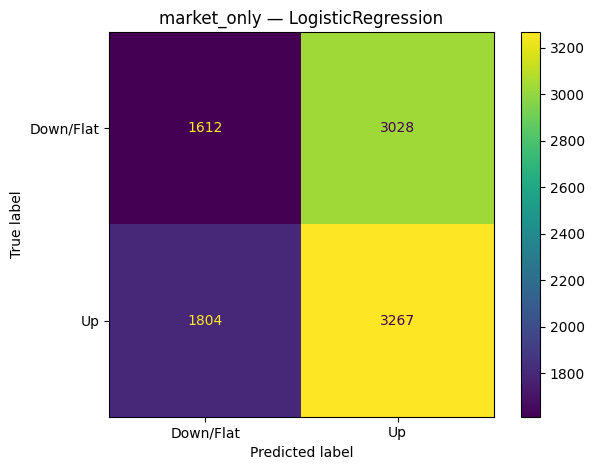

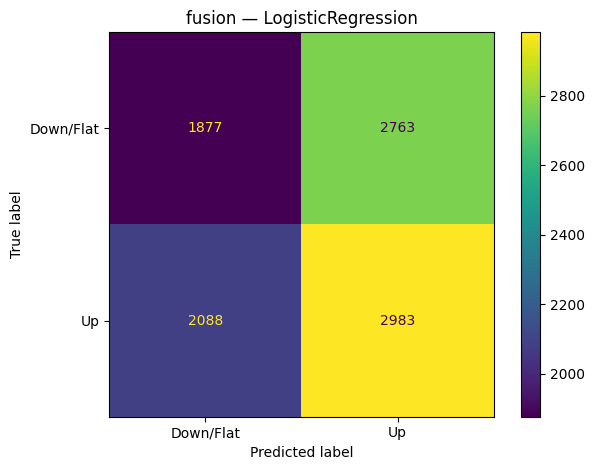

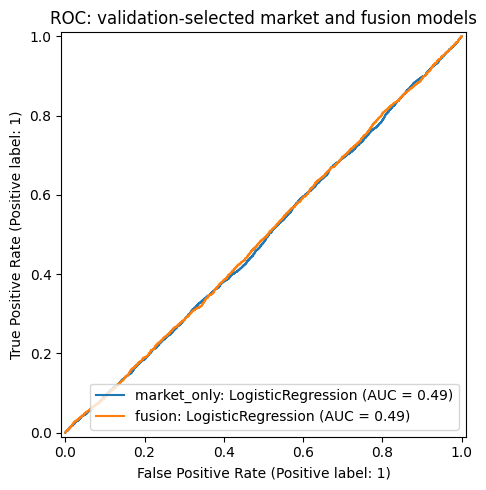

In [ ]:
def selected_name(fs): return best.loc[best.feature_set==fs,'model'].iloc[0]
sel_market=selected_name('market_only'); sel_fusion=selected_name('fusion')
for fs,name,file in [('market_only',sel_market,'10_confusion_matrix_selected_market.png'),('fusion',sel_fusion,'11_confusion_matrix_selected_fusion.png')]:
    q=pred_long[(pred_long.feature_set==fs)&(pred_long.model==name)]; cm=confusion_matrix(q.target,q.prediction,labels=[0,1]); ConfusionMatrixDisplay(cm,display_labels=['Down/Flat','Up']).plot(values_format='d'); plt.title(f'{fs} — {name}'); plt.tight_layout(); plt.savefig(FIGS/file,dpi=200); plt.show()
plt.figure(figsize=(8,5))
for fs,name in [('market_only',sel_market),('fusion',sel_fusion)]:
    q=pred_long[(pred_long.feature_set==fs)&(pred_long.model==name)]; RocCurveDisplay.from_predictions(q.target,q.prob_up,name=f'{fs}: {name}',ax=plt.gca())
plt.title('ROC: validation-selected market and fusion models'); plt.tight_layout(); plt.savefig(FIGS/'12_roc_selected_models.png',dpi=200); plt.show()

,ticker,fusion_records,fusion_accuracy,fusion_macro_f1,fusion_roc_auc,market_records,market_accuracy,market_macro_f1,market_roc_auc,macro_f1_improvement,accuracy_improvement
10,C,53,0.509434,0.507857,0.457143,53,0.433962,0.423913,0.417143,0.083944,0.075472
27,KO,236,0.516949,0.470352,0.527945,236,0.487288,0.397743,0.527945,0.072609,0.029661
46,WMT,234,0.551282,0.520819,0.536041,234,0.559829,0.477259,0.514814,0.043560,-0.008547
37,QQQ,233,0.515021,0.487493,0.487277,233,0.497854,0.444843,0.442149,0.042651,0.017167
23,GLD,204,0.519608,0.446818,0.498222,204,0.514706,0.406820,0.482649,0.039998,0.004902
24,GOOG,240,0.541667,0.541380,0.527360,240,0.512500,0.504229,0.496519,0.037151,0.029167
34,PEP,217,0.470046,0.432234,0.459643,217,0.460829,0.402119,0.453016,0.030115,0.009217
32,NVDA,240,0.458333,0.445865,0.473177,240,0.416667,0.416505,0.443555,0.029361,0.041667
1,AAPL,240,0.491667,0.488791,0.493990,240,0.495833,0.461014,0.466417,0.027777,-0.004167
42,TSM,220,0.536364,0.532500,0.512447,220,0.518182,0.509053,0.535605,0.023447,0.018182


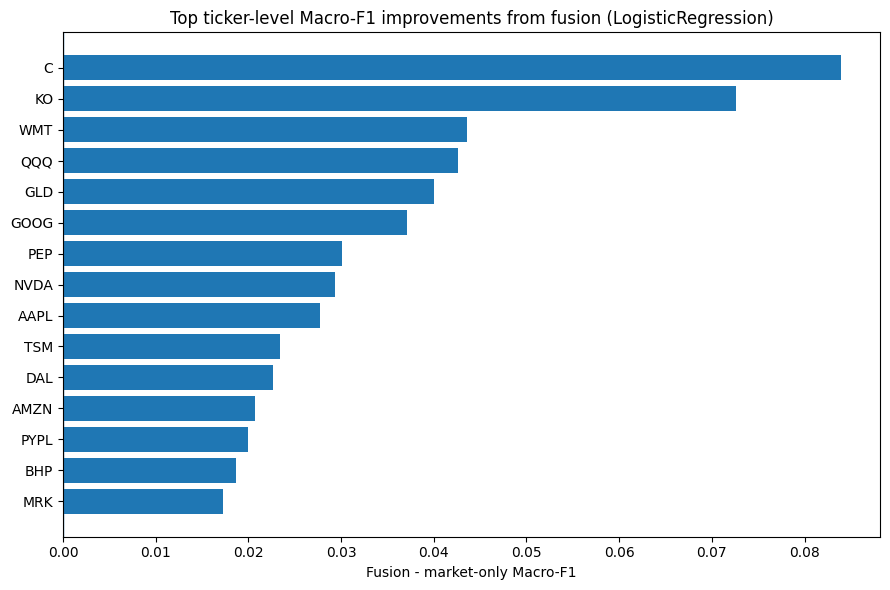

In [ ]:
fp=pred_long[(pred_long.feature_set=='fusion')&(pred_long.model==sel_fusion)].copy(); mp=pred_long[(pred_long.feature_set=='market_only')&(pred_long.model==sel_fusion)].copy()
def per_ticker(q,prefix):
    rows=[]
    for t,g in q.groupby('ticker'):
        if len(g)<10: continue
        rows.append({'ticker':t,f'{prefix}_records':len(g),f'{prefix}_accuracy':accuracy_score(g.target,g.prediction),f'{prefix}_macro_f1':f1_score(g.target,g.prediction,average='macro',zero_division=0),f'{prefix}_roc_auc':roc_auc_score(g.target,g.prob_up) if g.target.nunique()==2 else np.nan})
    return pd.DataFrame(rows)
pt=per_ticker(fp,'fusion').merge(per_ticker(mp,'market'),on='ticker'); pt['macro_f1_improvement']=pt.fusion_macro_f1-pt.market_macro_f1; pt['accuracy_improvement']=pt.fusion_accuracy-pt.market_accuracy; pt=pt.sort_values('macro_f1_improvement',ascending=False); pt.to_csv(TABLES/'20_per_ticker_test_performance.csv',index=False); display(pt.head(15)); z=pt.sort_values('macro_f1_improvement').tail(15); plt.figure(figsize=(9,6)); plt.barh(z.ticker,z.macro_f1_improvement); plt.axvline(0,linewidth=1); plt.title(f'Top ticker-level Macro-F1 improvements from fusion ({sel_fusion})'); plt.xlabel('Fusion - market-only Macro-F1'); plt.tight_layout(); plt.savefig(FIGS/'13_ticker_level_fusion_improvement.png',dpi=200); plt.show()

,feature,mean_abs_shap,feature_group
10,volatility_20,0.046271,Market
9,volatility_10,0.038915,Market
15,hl_range,0.032422,Market
17,rsi_14,0.029855,Market
4,ret_lag_5,0.028279,Market
11,momentum_5,0.027384,Market
8,volatility_5,0.025509,Market
6,ma_ratio_10,0.025463,Market
7,ma_ratio_20,0.023613,Market
3,ret_lag_3,0.023276,Market


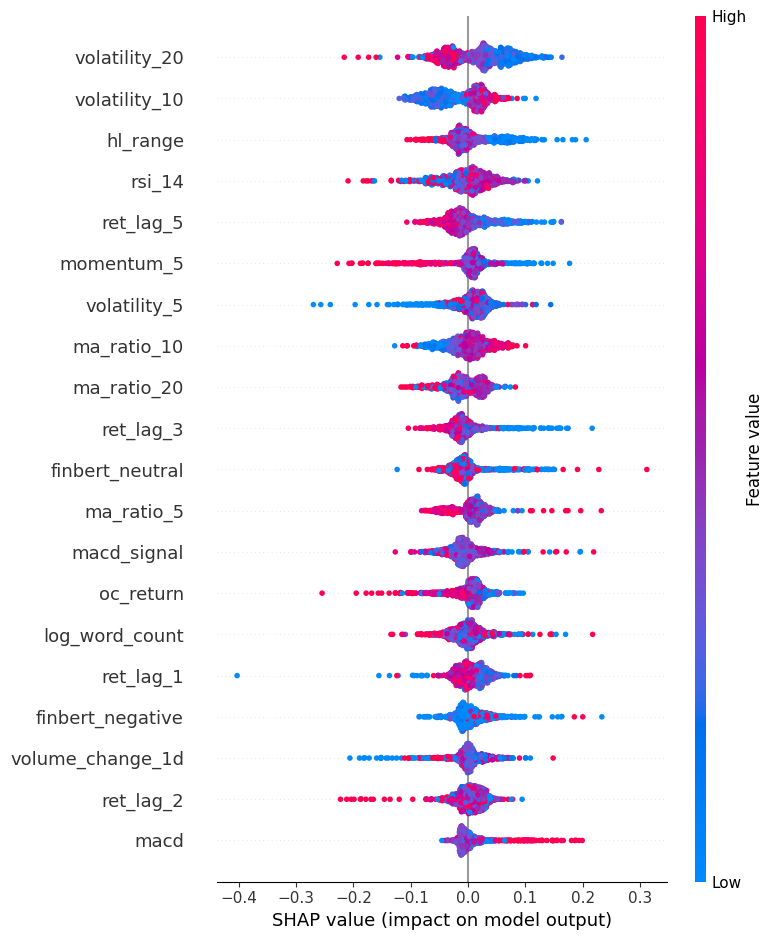

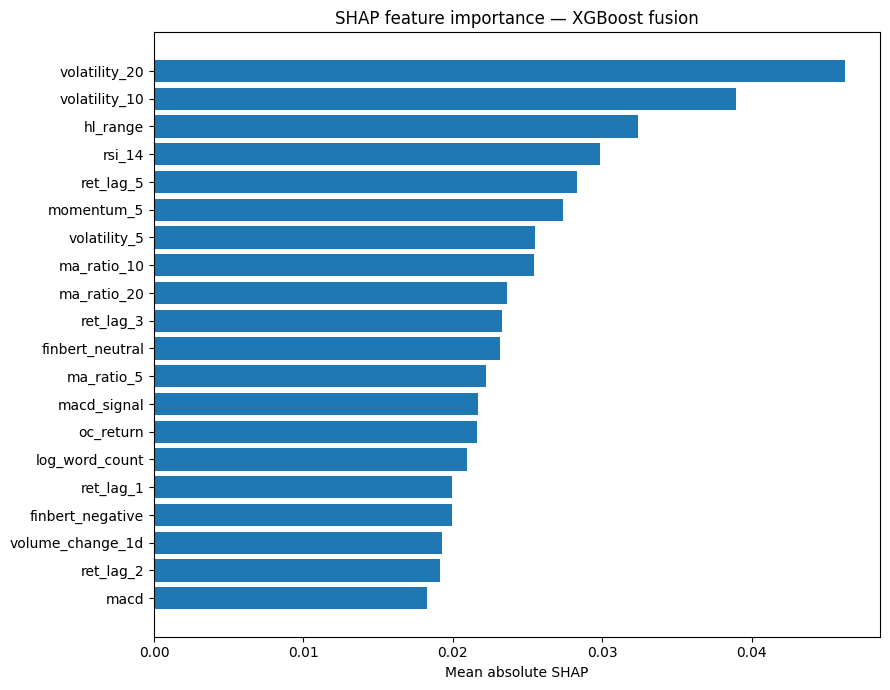

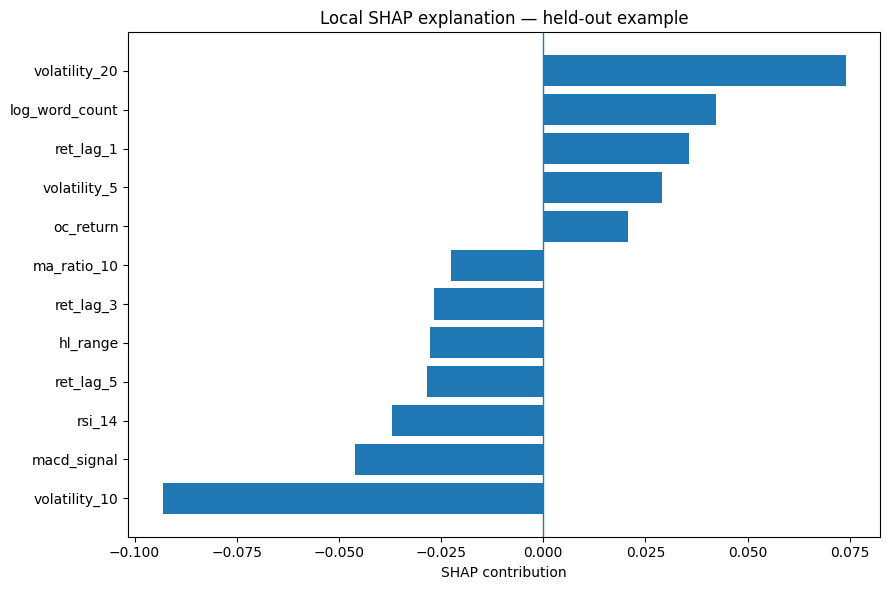

In [ ]:
# SHAP on XGBoost fusion model: efficient TreeSHAP comparison of market and sentiment features
SHAP_FEATURES=FEATURES['fusion']; pipe=final[('fusion','XGBoost')]; imp=pipe.named_steps['imputer']; est=pipe.named_steps['model']; X=imp.transform(test[SHAP_FEATURES]); rng=np.random.default_rng(SEED); n=min(SHAP_SAMPLE_SIZE,len(X)); ix=rng.choice(len(X),n,replace=False); XS=X[ix]; exp=shap.TreeExplainer(est); sv=exp.shap_values(XS); arr=np.asarray(sv[-1] if isinstance(sv,list) else sv); arr=arr[:,:,-1] if arr.ndim==3 else arr
if arr.shape[1]!=len(SHAP_FEATURES): raise RuntimeError(f'Unexpected SHAP shape {arr.shape}')
shap_imp=pd.DataFrame({'feature':SHAP_FEATURES,'mean_abs_shap':np.abs(arr).mean(0)}).sort_values('mean_abs_shap',ascending=False); shap_imp['feature_group']=shap_imp.feature.apply(lambda x:'Sentiment' if x in SENT else ('News volume' if x in NEWS else 'Market')); shap_imp.to_csv(TABLES/'21_shap_feature_importance.csv',index=False); display(shap_imp.head(15))
shap.summary_plot(arr,XS,feature_names=SHAP_FEATURES,show=False,max_display=20); plt.tight_layout(); plt.savefig(FIGS/'14_shap_beeswarm_xgboost_fusion.png',dpi=200,bbox_inches='tight'); plt.show(); z=shap_imp.head(20).sort_values('mean_abs_shap'); plt.figure(figsize=(9,7)); plt.barh(z.feature,z.mean_abs_shap); plt.title('SHAP feature importance — XGBoost fusion'); plt.xlabel('Mean absolute SHAP'); plt.tight_layout(); plt.savefig(FIGS/'15_shap_importance_xgboost_fusion.png',dpi=200); plt.show()
local=pd.DataFrame({'feature':SHAP_FEATURES,'feature_value':XS[0],'shap_value':arr[0]}); local['abs_shap']=local.shap_value.abs(); local=local.sort_values('abs_shap',ascending=False); local.to_csv(TABLES/'22_shap_local_example.csv',index=False); z=local.head(12).sort_values('shap_value'); plt.figure(figsize=(9,6)); plt.barh(z.feature,z.shap_value); plt.axvline(0,linewidth=1); plt.title('Local SHAP explanation — held-out example'); plt.xlabel('SHAP contribution'); plt.tight_layout(); plt.savefig(FIGS/'16_shap_local_example.png',dpi=200); plt.show()

## Week 4 — Dashboard, reproducibility package and dissertation evidence

In [ ]:
market_model=final[('market_only',sel_market)]; fusion_model=final[('fusion',sel_fusion)]; joblib.dump(market_model,MODELS/'selected_market_model.joblib'); joblib.dump(fusion_model,MODELS/'selected_fusion_model.joblib'); joblib.dump(final[('fusion','XGBoost')],MODELS/'xgboost_fusion_for_shap.joblib')
sp=pred_long[(pred_long.feature_set=='fusion')&(pred_long.model==sel_fusion)][['row_id','prediction','prob_up']]; dash_data=test[['row_id','ticker','date','close','next_return','target','sentiment_score','sentiment_label','finbert_positive','finbert_negative','finbert_neutral','word_count']].merge(sp,on='row_id',how='left'); dash_data.to_csv(DATA/'dashboard_test_data.csv',index=False)
proc=['row_id','ticker','date','split','target','next_return','close','word_count']+list(dict.fromkeys(MARKET+SENT+NEWS)); model_df[proc].to_parquet(DATA/'processed_modelling_dataset.parquet',index=False)

In [ ]:
app=r"""
from pathlib import Path
import pandas as pd, streamlit as st
B=Path(__file__).resolve().parent; D=pd.read_csv(B/'dashboard_test_data.csv',parse_dates=['date']); R=pd.read_csv(B/'selected_model_test_results.csv'); S=pd.read_csv(B/'shap_feature_importance.csv')
st.set_page_config(page_title='Financial News Sentiment Fusion',layout='wide'); st.title('Financial News Sentiment Fusion for Stock Market Forecasting'); st.caption('Research prototype — not financial advice and not a live trading system.')
st.subheader('Validation-selected model performance on held-out 2023 test data'); st.dataframe(R[['feature_set','model','accuracy','balanced_accuracy','macro_precision','macro_recall','macro_f1','roc_auc','log_loss']],use_container_width=True)
t=st.selectbox('Select ticker',sorted(D.ticker.unique())); d=D[D.ticker==t].sort_values('date'); c1,c2=st.columns(2)
with c1: st.subheader(f'{t} closing price'); st.line_chart(d.set_index('date')['close'])
with c2: st.subheader(f'{t} FinBERT sentiment'); st.line_chart(d.set_index('date')['sentiment_score'])
st.subheader('Forecast examples'); st.dataframe(d[['date','close','sentiment_score','sentiment_label','target','prediction','prob_up','next_return']].sort_values('date',ascending=False),use_container_width=True)
st.subheader('SHAP global feature importance'); st.bar_chart(S.head(20).set_index('feature')['mean_abs_shap']); st.markdown('Historical research outputs only; no trading execution or personalised advice.')
"""
(DASH/'app.py').write_text(app); shutil.copy2(DATA/'dashboard_test_data.csv',DASH/'dashboard_test_data.csv'); shutil.copy2(TABLES/'16_selected_model_test_results.csv',DASH/'selected_model_test_results.csv'); shutil.copy2(TABLES/'21_shap_feature_importance.csv',DASH/'shap_feature_importance.csv'); print('Dashboard:',DASH/'app.py')

Dashboard: /content/financial_news_sentiment_fusion/dashboard/app.py


In [ ]:
mrow=selected[selected.feature_set=='market_only'].iloc[0]; frow=selected[selected.feature_set=='fusion'].iloc[0]; research=pd.DataFrame([{'market_selected_model':mrow.model,'market_test_accuracy':mrow.accuracy,'market_test_macro_f1':mrow.macro_f1,'market_test_roc_auc':mrow.roc_auc,'fusion_selected_model':frow.model,'fusion_test_accuracy':frow.accuracy,'fusion_test_macro_f1':frow.macro_f1,'fusion_test_roc_auc':frow.roc_auc,'macro_f1_difference_fusion_minus_market':frow.macro_f1-mrow.macro_f1,'accuracy_difference_fusion_minus_market':frow.accuracy-mrow.accuracy,'interpretation_rule':'Positive differences support improvement; zero/negative differences do not.'}]); research.to_csv(TABLES/'23_research_answer_summary.csv',index=False); display(research.T)
excel=BASE/'Financial_News_Sentiment_Fusion_RESULTS.xlsx'
with pd.ExcelWriter(excel,engine='openpyxl') as w:
    for name,obj in [('Dataset_Summary',summary),('Target_Coverage',coverage),('Split_Counts',split_counts),('Target_Distribution',target_dist),('Leakage_Audit',audit),('Sentiment_Distribution',sc),('Validation_Baselines',base_val),('Validation_Results',val_results),('Validation_Selected',best),('Test_Baselines',base_test),('Test_All_Models',test_results),('Selected_Test_Results',selected),('Matched_Comparison',matched),('Uncertainty_Test',unc),('Per_Ticker',pt),('SHAP_Importance',shap_imp),('SHAP_Local',local),('Research_Answer',research)]: obj.to_excel(w,sheet_name=name[:31],index=False)
print('Excel:',excel)

,0
market_selected_model,LogisticRegression
market_test_accuracy,0.50242
market_test_macro_f1,0.487536
market_test_roc_auc,0.489757
fusion_selected_model,LogisticRegression
fusion_test_accuracy,0.500463
fusion_test_macro_f1,0.493899
fusion_test_roc_auc,0.492563
macro_f1_difference_fusion_minus_market,0.006363
accuracy_difference_fusion_minus_market,-0.001957


Excel: /content/financial_news_sentiment_fusion/Financial_News_Sentiment_Fusion_RESULTS.xlsx


In [ ]:
manifest={'project_title':CONFIG['project_title'],'dataset':DATASET_ID,'original_dataset_reference':ORIGINAL_DATASET_ID,'finbert_model':FINBERT_MODEL,'device':str(DEVICE),'train_records':int((model_df.split=='train').sum()),'validation_records':int((model_df.split=='validation').sum()),'test_records':int((model_df.split=='test').sum()),'tickers':int(model_df.ticker.nunique()),'selected_market_model':sel_market,'selected_fusion_model':sel_fusion,'selection_metric':'validation macro_f1','test_year':2023}; (BASE/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
guide="""FINANCIAL NEWS SENTIMENT FUSION — REPORT EVIDENCE GUIDE

CHAPTER 3: 02_dataset_summary.csv; 05_target_coverage.csv; 06_split_counts.csv; 08_leakage_audit.csv; 10_feature_dictionary.csv; methodology_config.json

CHAPTER 4 EDA: figures 01–07. MODEL RESULTS: figures 08–13 and tables 12, 14, 16, 18, 19, 20, 23. EXPLAINABILITY: figures 14–16 and tables 21–22.

Do not claim sentiment fusion improved forecasting unless held-out test results support that conclusion.
"""; (BASE/'REPORT_EVIDENCE_GUIDE.txt').write_text(guide); print(guide)

FINANCIAL NEWS SENTIMENT FUSION — REPORT EVIDENCE GUIDE

CHAPTER 3: 02_dataset_summary.csv; 05_target_coverage.csv; 06_split_counts.csv; 08_leakage_audit.csv; 10_feature_dictionary.csv; methodology_config.json

CHAPTER 4 EDA: figures 01–07. MODEL RESULTS: figures 08–13 and tables 12, 14, 16, 18, 19, 20, 23. EXPLAINABILITY: figures 14–16 and tables 21–22.

Do not claim sentiment fusion improved forecasting unless held-out test results support that conclusion.



In [ ]:
!pip -q install streamlit

In [ ]:
!streamlit run /content/financial_news_sentiment_fusion/dashboard/app.py --server.port 8501 &>/content/streamlit.log &

In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 6s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠴

In [ ]:
!lt --port 8501

your url is: https://tidy-pigs-scream.loca.lt
